# IMPORT LIBRARY

In [57]:
from google_play_scraper import app, reviews, Sort, reviews_all

import pandas as pd

# NONAKTIFKAN PERINGATAN CHAINING
pd.options.mode.chained_assignment 

import numpy as np

# MENGATUR SEED UNTUK PRODUKTIVITAS
seed = 0
np.random.seed(seed)

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score

import datetime as dt
import re
import string
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords

from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

from wordcloud import WordCloud

import nltk
nltk.download('punkt_tab')
nltk.download('stopwords')

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\tabiz\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\tabiz\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

# SCRAPING DATASET

In [58]:
scrapreview, _ = reviews(
    'com.byu.id',
    lang='id',
    country='id',
    sort=Sort.MOST_RELEVANT,
    count=1000
)

# IMPORT TO CSV AND LOAD DATA

In [59]:
import csv

with open('app_reviews.csv', mode='w', newline='', encoding='utf-8') as file:
    writer = csv.writer(file)
    writer.writerow(['Review'])
    for review in scrapreview:
        writer.writerow([review['content']])

# LOAD DATASET

In [60]:
app_reviews_df = pd.DataFrame(scrapreview)
app_reviews_df.to_csv('app_reviews.csv', index=False)

app_reviews_df.shape
jumlah_ulasan, jumlah_kolom = app_reviews_df.shape
app_reviews_df.head()

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
0,6efc656e-17f2-4899-b6e8-ee227dcee06e,Dhieya Faeyza Salim,https://play-lh.googleusercontent.com/a-/ALV-U...,"by u kenapa aplikasi nya ngelag banget, nunggu...",3,4,1.64.6,2026-06-04 06:46:25,"Hai Kak, maaf ya udah bikin ga nyaman ya.Terka...",2026-06-04 06:50:29,1.64.6
1,be6b8d88-1bd9-4b01-ab5e-268ac84fec4b,Malfriando Sinay09,https://play-lh.googleusercontent.com/a-/ALV-U...,"awalnya harga paket internet murah, namun seka...",1,3,1.64.6,2026-06-03 05:36:42,"Hai Kak, kenaikan harga menyesuaikan UU No. 7 ...",2026-06-03 05:46:35,1.64.6
2,fc3ce8ed-dc14-46af-871f-5b01b9bc3a4a,Kram X NCT,https://play-lh.googleusercontent.com/a-/ALV-U...,sinyal nya tambah lama tambah ngelag trus data...,1,4,1.64.6,2026-05-31 08:34:00,"Hai Kak, maaf nih terkait kendalanya, bisa cob...",2026-05-31 08:38:58,1.64.6
3,e7fe2eaf-33bd-4e35-b01f-65bf847d595c,Steven Renyaan,https://play-lh.googleusercontent.com/a/ACg8oc...,Halo tim By.U 👋 Saya berharap By.U dapat lebih...,5,5,1.64.6,2026-05-31 20:19:52,"Hai, Kak! Makasih banyak buat Rating Positive ...",2026-05-31 20:26:25,1.64.6
4,d6e1427d-4ef6-4543-a351-d3396af40e8a,Kekey Dalwish,https://play-lh.googleusercontent.com/a/ACg8oc...,bagus pake by.u tuh ga ush mikirin lagi perpan...,5,3,1.64.6,2026-06-02 12:13:32,"Hai Kak Kekey, makasih banyak buat rating nya....",2026-06-02 12:16:24,1.64.6


In [61]:
app_reviews_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   reviewId              1000 non-null   str           
 1   userName              1000 non-null   str           
 2   userImage             1000 non-null   str           
 3   content               1000 non-null   str           
 4   score                 1000 non-null   int64         
 5   thumbsUpCount         1000 non-null   int64         
 6   reviewCreatedVersion  1000 non-null   str           
 7   at                    1000 non-null   datetime64[us]
 8   replyContent          995 non-null    str           
 9   repliedAt             995 non-null    datetime64[us]
 10  appVersion            1000 non-null   str           
dtypes: datetime64[us](2), int64(2), str(7)
memory usage: 829.2 KB


# DROP MISSING VALUES

In [62]:
clean_df = app_reviews_df.dropna()

# DROP DUPLICATES

In [63]:
clean_df = clean_df.drop_duplicates()

In [64]:
clean_df.info()

<class 'pandas.DataFrame'>
Index: 995 entries, 0 to 999
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   reviewId              995 non-null    str           
 1   userName              995 non-null    str           
 2   userImage             995 non-null    str           
 3   content               995 non-null    str           
 4   score                 995 non-null    int64         
 5   thumbsUpCount         995 non-null    int64         
 6   reviewCreatedVersion  995 non-null    str           
 7   at                    995 non-null    datetime64[us]
 8   replyContent          995 non-null    str           
 9   repliedAt             995 non-null    datetime64[us]
 10  appVersion            995 non-null    str           
dtypes: datetime64[us](2), int64(2), str(7)
memory usage: 834.8 KB


# TEXT PREPROCESSING

In [65]:
def cleaningText(text):
    text = re.sub(r'@[A-Za-z0-9]+', '', text) # MENGHAPUS MENTION
    text = re.sub(r'#[A-Za-z0-9]+', '', text) # MENGHAPUS HASHTAG
    text = re.sub(r'RT[\s]', '', text) # MENGHAPUS RT
    text = re.sub(r'@http\S+', '', text) # MENGHAPUS LINK
    text = re.sub(r'[0-9]+', '', text) # MENGHAPUS ANGKA
    text = re.sub(r'[^\w\s]', '', text) # MENGHAPUS KARAKTER SELAIN HURUF DAN ANGKA

    text = text.replace('\n', ' ') # GANTI BARIS BARU DENGAN SPASI
    text = text.translate(str.maketrans('', '', string.punctuation)) # HAPUS SEMUA TANDA BACA
    text = text.strip(' ') # HAPUS SPASI KANAN KIRI
    return text

def caseFoldingText(text):
    text = text.lower()
    return text

def tokenizingText(text):
    text = word_tokenize(text)
    return text

def filteringText(text):
    listStopwords = set(stopwords.words('indonesian'))
    listStopwords1 = set(stopwords.words('english'))
    listStopwords.update(listStopwords1)
    listStopwords.update(['iya','yaa','gak','nya','na','sih','ku',"di","ga","ya","gaa","loh","kah","woi","woii","woy"])
    filtered = []
    for txt in text:
        if txt not in listStopwords:
            filtered.append(txt)
    text = filtered
    return text

def stemmingText(text):
    factory = StemmerFactory()
    stemmer = factory.create_stemmer()

    words = text.split()

    stemmed_words = [stemmer.stem(word) for word in words]

    stemmed_text = ' '.join(stemmed_words)

    return stemmed_text

def toSentence(list_words):
    sentence = ' '.join(word for word in list_words)
    return sentence

slangwords = {"@": "di", "abis": "habis", "wtb": "beli", "masi": "masih", "wts": "jual", "wtt": "tukar", "bgt": "banget", "maks": "maksimal"}

def fixSlangWords(text):
    words = text.split()
    fixed_words = []

    for word in words:
        if word.lower() in slangwords:
            fixed_words.append(slangwords[word.lower()])
        else:
            fixed_words.append(word)
    
    fixed_text = ' '.join(fixed_words)
    return fixed_text

In [66]:
clean_df['text_clean'] = clean_df['content'].apply(cleaningText)
clean_df['text_casefoldingText'] = clean_df['text_clean'].apply(caseFoldingText)
clean_df['text_slangwords'] = clean_df['text_casefoldingText'].apply(fixSlangWords)
clean_df['text_tokenizingText'] = clean_df['text_slangwords'].apply(tokenizingText)
clean_df['text_stopword'] = clean_df['text_tokenizingText'].apply(filteringText)
clean_df['text_akhir'] = clean_df['text_stopword'].apply(toSentence)

clean_df.head()

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion,text_clean,text_casefoldingText,text_slangwords,text_tokenizingText,text_stopword,text_akhir
0,6efc656e-17f2-4899-b6e8-ee227dcee06e,Dhieya Faeyza Salim,https://play-lh.googleusercontent.com/a-/ALV-U...,"by u kenapa aplikasi nya ngelag banget, nunggu...",3,4,1.64.6,2026-06-04 06:46:25,"Hai Kak, maaf ya udah bikin ga nyaman ya.Terka...",2026-06-04 06:50:29,1.64.6,by u kenapa aplikasi nya ngelag banget nunggu ...,by u kenapa aplikasi nya ngelag banget nunggu ...,by u kenapa aplikasi nya ngelag banget nunggu ...,"[by, u, kenapa, aplikasi, nya, ngelag, banget,...","[u, aplikasi, ngelag, banget, nunggu, loading,...",u aplikasi ngelag banget nunggu loading screen...
1,be6b8d88-1bd9-4b01-ab5e-268ac84fec4b,Malfriando Sinay09,https://play-lh.googleusercontent.com/a-/ALV-U...,"awalnya harga paket internet murah, namun seka...",1,3,1.64.6,2026-06-03 05:36:42,"Hai Kak, kenaikan harga menyesuaikan UU No. 7 ...",2026-06-03 05:46:35,1.64.6,awalnya harga paket internet murah namun sekar...,awalnya harga paket internet murah namun sekar...,awalnya harga paket internet murah namun sekar...,"[awalnya, harga, paket, internet, murah, namun...","[harga, paket, internet, murah, harga, paket, ...",harga paket internet murah harga paket hapus s...
2,fc3ce8ed-dc14-46af-871f-5b01b9bc3a4a,Kram X NCT,https://play-lh.googleusercontent.com/a-/ALV-U...,sinyal nya tambah lama tambah ngelag trus data...,1,4,1.64.6,2026-05-31 08:34:00,"Hai Kak, maaf nih terkait kendalanya, bisa cob...",2026-05-31 08:38:58,1.64.6,sinyal nya tambah lama tambah ngelag trus data...,sinyal nya tambah lama tambah ngelag trus data...,sinyal nya tambah lama tambah ngelag trus data...,"[sinyal, nya, tambah, lama, tambah, ngelag, tr...","[sinyal, ngelag, trus, data, dikit, sebentar, ...",sinyal ngelag trus data dikit sebentar bagus n...
3,e7fe2eaf-33bd-4e35-b01f-65bf847d595c,Steven Renyaan,https://play-lh.googleusercontent.com/a/ACg8oc...,Halo tim By.U 👋 Saya berharap By.U dapat lebih...,5,5,1.64.6,2026-05-31 20:19:52,"Hai, Kak! Makasih banyak buat Rating Positive ...",2026-05-31 20:26:25,1.64.6,Halo tim ByU Saya berharap ByU dapat lebih me...,halo tim byu saya berharap byu dapat lebih me...,halo tim byu saya berharap byu dapat lebih men...,"[halo, tim, byu, saya, berharap, byu, dapat, l...","[halo, tim, byu, berharap, byu, mengoptimalkan...",halo tim byu berharap byu mengoptimalkan kuali...
4,d6e1427d-4ef6-4543-a351-d3396af40e8a,Kekey Dalwish,https://play-lh.googleusercontent.com/a/ACg8oc...,bagus pake by.u tuh ga ush mikirin lagi perpan...,5,3,1.64.6,2026-06-02 12:13:32,"Hai Kak Kekey, makasih banyak buat rating nya....",2026-06-02 12:16:24,1.64.6,bagus pake byu tuh ga ush mikirin lagi perpanj...,bagus pake byu tuh ga ush mikirin lagi perpanj...,bagus pake byu tuh ga ush mikirin lagi perpanj...,"[bagus, pake, byu, tuh, ga, ush, mikirin, lagi...","[bagus, pake, byu, tuh, ush, mikirin, perpanja...",bagus pake byu tuh ush mikirin perpanjang kart...


# LABELING

In [67]:
import csv
import requests
from io import StringIO

# Membaca data kamus kata-kata positif dari GitHub
lexicon_positive = dict()

# Mengirim permintaan HTTP untuk mendapatkan file CSV dari GitHub
response = requests.get('https://raw.githubusercontent.com/angelmetanosaa/dataset/main/lexicon_positive.csv')

# Jika permintaan berhasil
if response.status_code == 200:
    # Membaca teks respons sebagai file CSV menggunakan pembaca CSV dengan pemisah koma
    reader = csv.reader(StringIO(response.text), delimiter=',')

    # Mengulangi setiap baris dalam file CSV
    for row in reader:
        # Menambahkan kata-kata positif dan skornya ke dalam kamus lexicon_positive
        lexicon_positive[row[0]] = int(row[1])
else:
    print("Failed to fetch positive lexiocn data")

# Membaca data kamus kata-kata negatif dari GitHub
lexicon_negative = dict()

# Mengirim permintaan HTTP untuk mendapatkan file CSV dari GitHub
response = requests.get('https://raw.githubusercontent.com/angelmetanosaa/dataset/main/lexicon_negative.csv')

# Jika permintaan berhasil
if response.status_code == 200:
    # Membaca teks respons sebagai file CSV menggunakan pembaca CSV dengan pemisah koma
    reader = csv.reader(StringIO(response.text), delimiter=',')

    # Mengulangi setiap baris dalam file CSV
    for row in reader:
        # Menambahkan kata-kata positif dan skornya ke dalam kamus lexicon_positive
        lexicon_negative[row[0]] = int(row[1])
else:
    print("Failed to fetch negative lexiocn data")


# POLARITY

In [68]:
def sentiment_analysis_lexicon_indonesia(text):
    score = 0

    for word in text:
        if (word in lexicon_positive):
            score = score + lexicon_positive[word]
    
    for word in text:
        if (word in lexicon_negative):
            score = score + lexicon_negative[word]

    polarity = ''

    if (score >= 0):
        polarity = 'positive'
    
    elif (score < 0):
        polarity = 'negative'
    
    return score, polarity

In [69]:
results = clean_df['text_stopword'].apply(sentiment_analysis_lexicon_indonesia)
results = list(zip(*results))
clean_df['polarity_score'] = results[0]
clean_df['polarity'] = results[1]
print(clean_df['polarity'].value_counts())

polarity
negative    725
positive    270
Name: count, dtype: int64


# EDA

## POLARITY

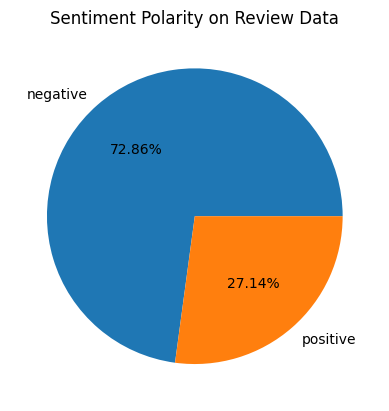

In [70]:
plt.Figure(figsize=(8, 8))
plt.pie(x=clean_df['polarity'].value_counts(), labels=['negative', 'positive'], autopct='%.2f%%')
plt.title("Sentiment Polarity on Review Data")
plt.show()

## WORDCLOUD

<function matplotlib.pyplot.show(close=None, block=None)>

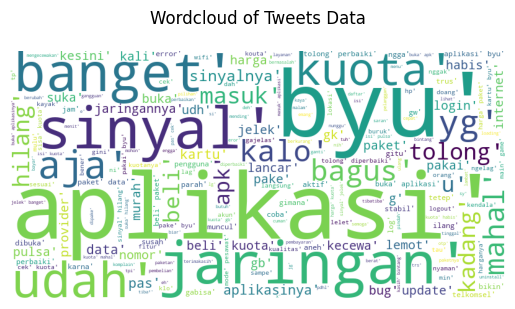

In [71]:
text = " ".join(clean_df['text_stopword'].astype(str))

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white',
    colormap='viridis'
).generate(text)

plt.Figure(figsize=(10, 5))
plt.imshow(wordcloud)
plt.axis('off')
plt.title('Wordcloud of Tweets Data', pad=20)
plt.show

## WORDCLOUD NEGATIVE

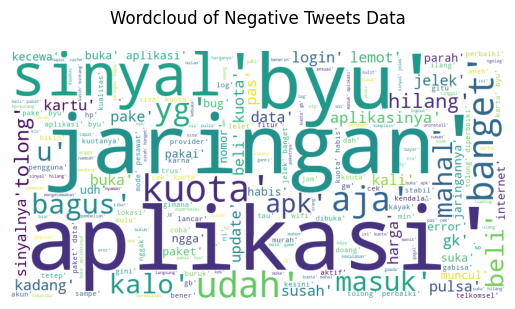

In [72]:
text_negative = " ".join(clean_df[clean_df['polarity'] == 'negative']['text_stopword'].astype(str))

wordcloud_negative = WordCloud(
    height=400,
    width=800,
    background_color='white',
    colormap='viridis'
).generate(text_negative)

plt.Figure(figsize=(10, 5))
plt.imshow(wordcloud_negative)
plt.title("Wordcloud of Negative Tweets Data", pad=20)
plt.axis('off')
plt.show()

## WORDCLOUD POSITIVE

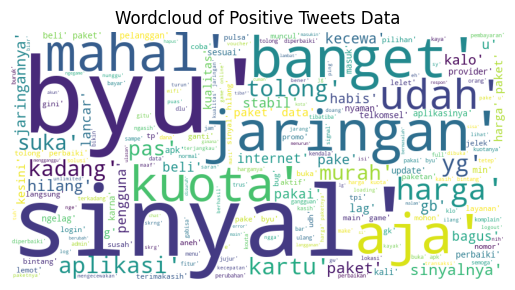

In [73]:
text_positive = " ".join(clean_df[clean_df['polarity'] == 'positive']['text_stopword'].astype(str))

wordcloud_positive = WordCloud(
    width=800,
    height=400,
    background_color='white',
    colormap='viridis'
).generate(text_positive)

plt.Figure(figsize=(10, 5))
plt.imshow(wordcloud_positive)
plt.title("Wordcloud of Positive Tweets Data")
plt.axis('off')
plt.show()

# DATA SPLIT & FEATURE EXTRACTION (TF-IDF)

In [74]:
# DATA SPLIT
x = clean_df['text_akhir']
y = clean_df['polarity']

# FEATURE EXTRACTION
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=200, min_df=17, max_df=0.8)
x_tfidf = tfidf.fit_transform(x)

features_df = pd.DataFrame(x_tfidf.toarray(), columns=tfidf.get_feature_names_out())

features_df

,aja,akses,aktif,akun,aman,aneh,apk,aplikasi,aplikasinya,bagus,...,tpi,trus,tuh,udah,udh,ulang,uninstall,update,wifi,yg
0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.076233,0.0,0.000000,...,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.000000
1,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.000000,...,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.000000
2,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.230356,...,0.0,0.341297,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.000000
3,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.000000,...,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.000000
4,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.145233,...,0.0,0.000000,0.259158,0.000000,0.198572,0.000000,0.0,0.000000,0.0,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
990,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.000000,...,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.000000
991,0.0,0.0,0.0,0.0,0.0,0.000000,0.176420,0.000000,0.0,0.000000,...,0.0,0.000000,0.000000,0.415725,0.000000,0.203129,0.0,0.197229,0.0,0.000000
992,0.0,0.0,0.0,0.0,0.0,0.333469,0.000000,0.176136,0.0,0.000000,...,0.0,0.000000,0.000000,0.216605,0.000000,0.000000,0.0,0.308286,0.0,0.000000
993,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.148881,...,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.152772


# DATA SPLIT

In [75]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x_tfidf, y, test_size=0.2, random_state=42)

# MODELING

## NAIVE BAYES

In [76]:
from sklearn.naive_bayes import BernoulliNB

nb = BernoulliNB()

nb.fit(x_train.toarray(), y_train)

y_pred_train_nb = nb.predict(x_train.toarray())
y_pred_test_nb = nb.predict(x_test.toarray())

accuracy_train_nb = accuracy_score(y_pred_train_nb, y_train)
accuracy_test_nb = accuracy_score(y_pred_test_nb, y_test)

print("Naive Bayes Train Accuracy:", accuracy_train_nb)
print("Naive Bayes Test Accuracy:", accuracy_test_nb)

Naive Bayes Train Accuracy: 0.8454773869346733
Naive Bayes Test Accuracy: 0.7839195979899497


## RANDOM FOREST

In [77]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier()

rf.fit(x_train.toarray(), y_train)

y_pred_train_rf = rf.predict(x_train.toarray())
y_pred_test_rf = rf.predict(x_test.toarray())

accuracy_train_rf = accuracy_score(y_pred_train_rf, y_train)
accuracy_test_rf = accuracy_score(y_pred_test_rf, y_test)

print("Random Forest Train Accuracy:", accuracy_train_rf)
print("Random Forest Test Accuracy:", accuracy_test_rf)

Random Forest Train Accuracy: 1.0
Random Forest Test Accuracy: 0.7839195979899497


## LOGISTIC REGRESSION

In [78]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression()

lr.fit(x_train.toarray(), y_train)

y_pred_train_lr = lr.predict(x_train.toarray())
y_pred_test_lr = lr.predict(x_test.toarray())

accuracy_train_lr = accuracy_score(y_pred_train_lr, y_train)
accuracy_test_lr = accuracy_score(y_pred_test_lr, y_test)

print("Logistic Regression Train Accuracy:", accuracy_train_lr)
print("Logistic Regression Test Accuracy:", accuracy_test_lr)

Logistic Regression Train Accuracy: 0.8655778894472361
Logistic Regression Test Accuracy: 0.8140703517587939


## DECISION TREE

In [79]:
from sklearn.tree import DecisionTreeClassifier

from sklearn.naive_bayes import BernoulliNB

dt = DecisionTreeClassifier()

dt.fit(x_train.toarray(), y_train)

y_pred_train_dt = dt.predict(x_train.toarray())
y_pred_test_dt = dt.predict(x_test.toarray())

accuracy_train_dt = accuracy_score(y_pred_train_dt, y_train)
accuracy_test_dt = accuracy_score(y_pred_test_dt, y_test)

print("Naive Bayes Train Accuracy:", accuracy_train_dt)
print("Naive Bayes Test Accuracy:", accuracy_test_dt)

Naive Bayes Train Accuracy: 1.0
Naive Bayes Test Accuracy: 0.7688442211055276
